BASIC CODE TO NAVIGATE THROUGH THE REGISTERS IN A SESSION DIRECTORY

In [9]:
from utils.data_loading import load_rig_info, available_devices, possible_registers, read_harp_register

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

verbose = True


base_path = r"C:\Users\daniel.alvarez\Desktop\ReRun\Other\828425_2026-01-16T170304Z"
rig_data = load_rig_info(base_path)

device_list = available_devices(base_path)
print(f"Possible registers in this folder: {device_list}")

device_name = device_list[0]  
registers = possible_registers(base_path, device_name)
print(f"Possible registers in {device_name}: {registers}")


Loaded rig info: Computer - YACUMAMA, Rig - 4C
Possible registers in this folder: ['Behavior.harp', 'ClockGenerator.harp', 'EnvironmentSensor.harp', 'Lickometer.harp', 'Olfactometer.harp', 'SniffDetector.harp', 'StepperDriver.harp', 'Treadmill.harp']
Possible registers in Behavior.harp: ['AnalogData', 'AssemblyVersion', 'Camera0Frame', 'Camera0Frequency', 'Camera1Frame', 'Camera1Frequency', 'ClockConfiguration', 'CoreVersionHigh', 'CoreVersionLow', 'DeviceName', 'DigitalInputState', 'DisableServos', 'EnableEncoders', 'EnableSerialTimestamp', 'EnableServos', 'EncoderMode', 'EncoderReset', 'EventEnable', 'FirmwareVersionHigh', 'FirmwareVersionLow', 'HardwareVersionHigh', 'HardwareVersionLow', 'Led0Current', 'Led0MaxCurrent', 'Led1Current', 'Led1MaxCurrent', 'MimicPort0IR', 'MimicPort0Valve', 'MimicPort1IR', 'MimicPort1Valve', 'MimicPort2IR', 'MimicPort2Valve', 'OperationControl', 'OutputClear', 'OutputPulseEnable', 'OutputSet', 'OutputState', 'OutputToggle', 'PokeInputFilter', 'PortDIOCl

In [10]:
# Filtering registers by number of rows

def registers_with_min_rows(base_path: str, harp_name: str, min_rows: int, include_common_registers: bool = False,
) -> list[str]:
    """
    For a given HARP device, return registers that have more than (or at least) `min_rows` rows.

    Parameters
    ----------
    base_path : str
        Root path containing the 'behavior' folder.
    harp_name : str
        Device file, e.g., 'AnalogInput.harp' or 'Olfactometer.harp'.
    min_rows : int
        Threshold for filtering by number of rows.
    include_common_registers : bool, optional
        Whether to include common registers when creating the reader. Default False.


    Returns
    -------
    list[str]
        The registers meeting the threshold, as names.
    """
 
    all_regs = read_harp_register(base_path, harp_name)

    if not isinstance(all_regs, dict):
        raise RuntimeError("Expected a dict of DataFrames when reading all registers.")

    # Compute row counts and filter
    counts: dict[str, int] = {}
    for name, df in all_regs.items():
        # Defensive: ensure it's a DataFrame and handle odd cases
        try:
            n_rows = int(getattr(df, "shape", (0, 0))[0])
        except Exception:
            n_rows = 0
        counts[name] = n_rows

    filtered = {k: v for k, v in counts.items() if v >= min_rows}

    # Return shape requested
    return sorted(filtered.keys())

def devices_registers_with_min_rows(base_path: str, min_rows: int, include_common_registers: bool = False
    ) -> dict[str, list[str] | dict[str, int]]:
    """
    For every available device in `base_path/behavior`, return the registers with more than/at least `min_rows` rows.

    Returns
    -------
    dict[str, list[str] | dict[str, int]]
        Mapping device_name -> registers that meet the threshold
    """
    results: dict[str , list[str] | dict[str, int]] = {}
    for device in available_devices(base_path):
        try:
            results[device] = registers_with_min_rows(base_path, device, min_rows, include_common_registers=include_common_registers)
        except Exception as e:
            if verbose:
                print(f"[WARN] Skipped {device}: {e}")
    return results

register_to_graph = devices_registers_with_min_rows(base_path, min_rows=20)
register_to_graph

[WARN] Skipped StepperDriver.harp: expected payload type uint8 but got uint16


{'Behavior.harp': ['Camera0Frame',
  'DigitalInputState',
  'OutputSet',
  'PulseSupplyPort0',
  'PwmStart',
  'TimestampSeconds'],
 'ClockGenerator.harp': ['Counter', 'TimestampSeconds'],
 'EnvironmentSensor.harp': ['SensorData', 'TimestampSeconds'],
 'Lickometer.harp': ['LickState', 'TimestampSeconds'],
 'Olfactometer.harp': ['Channel0ActualFlow',
  'Channel1ActualFlow',
  'Channel2ActualFlow',
  'Channel3ActualFlow',
  'Channel4ActualFlow',
  'ChannelsTargetFlow',
  'EndValveState',
  'Flowmeter',
  'OdorValveState',
  'TimestampSeconds'],
 'SniffDetector.harp': ['RawVoltage', 'TimestampSeconds'],
 'Treadmill.harp': ['BrakeCurrentSetPoint', 'SensorData', 'TimestampSeconds']}

[WARN] Skipped StepperDriver.harp: expected payload type uint8 but got uint16
Registers with at least 10 rows: {'Behavior.harp': ['Camera0Frame', 'DigitalInputState', 'OutputSet', 'PulseSupplyPort0', 'PwmStart', 'TimestampSeconds'], 'ClockGenerator.harp': ['Counter', 'TimestampSeconds'], 'EnvironmentSensor.harp': ['SensorData', 'TimestampSeconds'], 'Lickometer.harp': ['LickState', 'TimestampSeconds'], 'Olfactometer.harp': ['Channel0ActualFlow', 'Channel1ActualFlow', 'Channel2ActualFlow', 'Channel3ActualFlow', 'Channel4ActualFlow', 'ChannelsTargetFlow', 'EndValveState', 'Flowmeter', 'OdorValveState', 'TimestampSeconds'], 'SniffDetector.harp': ['RawVoltage', 'TimestampSeconds'], 'Treadmill.harp': ['BrakeCurrentSetPoint', 'SensorData', 'TimestampSeconds']}
Selected registers for plotting: {'Lickometer.harp': ['LickState'], 'Olfactometer.harp': ['ChannelsTargetFlow', 'Channel0ActualFlow', 'EndValveState', 'Flowmeter', 'OdorValveState'], 'SniffDetector.harp': ['RawVoltage'], 'Treadmill.harp

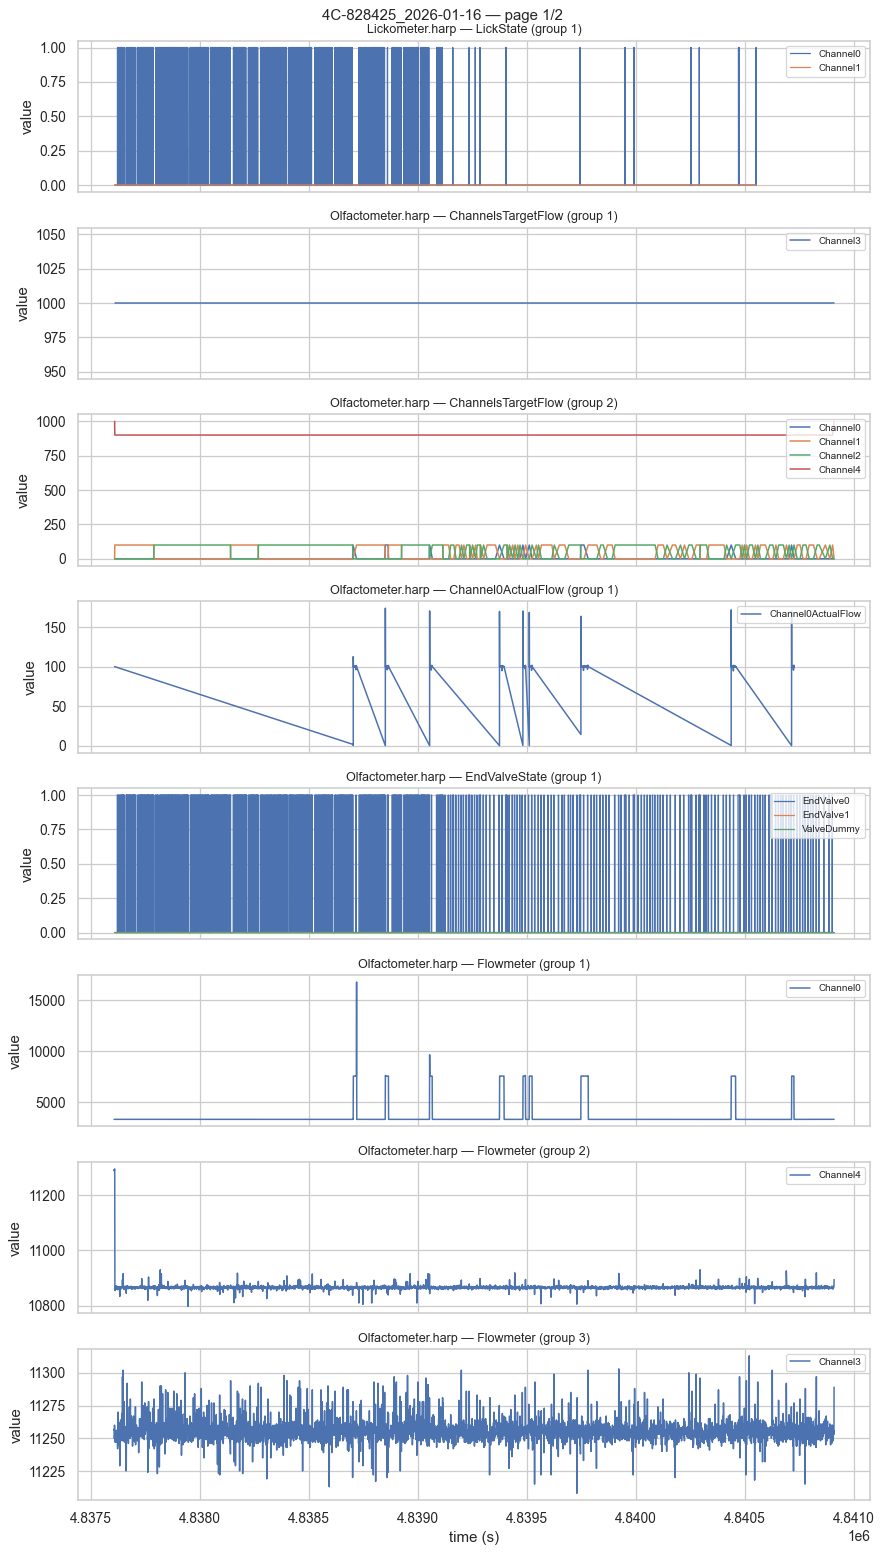

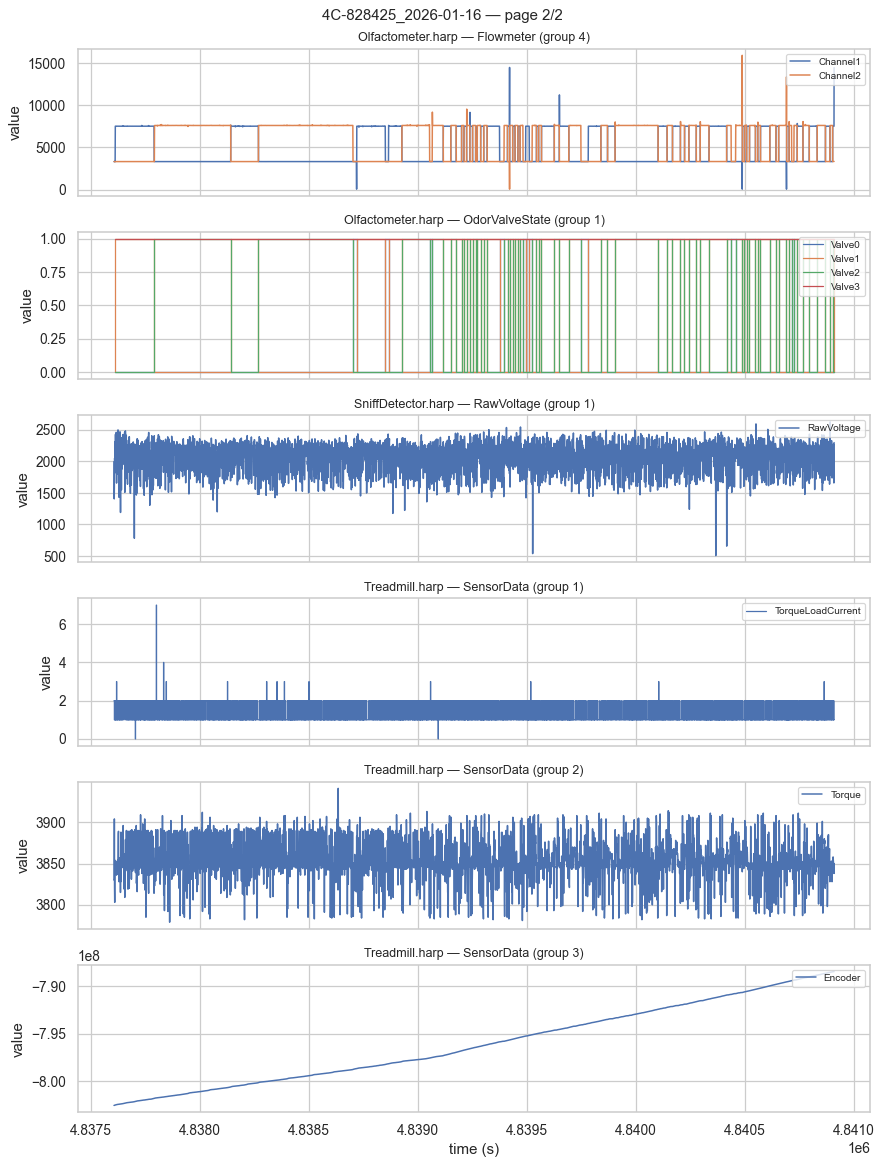

In [4]:
### Graphs

from typing import Dict, List, Optional, Sequence, Tuple, Union
import math

# ---------- Time axis helper ----------
_TIME_COLS = {"TimestampSeconds", "timestamp", "time"}

def _coerce_time_axis(df: pd.DataFrame,
                      time_col_candidates: Sequence[str] = ("TimestampSeconds", "timestamp", "time")
                      ) -> np.ndarray:
    for c in time_col_candidates:
        if c in df.columns:
            x = df[c].to_numpy()
            if np.issubdtype(getattr(x, "dtype", np.array([0]).dtype), np.number):
                return x
            try:
                ts = pd.to_datetime(df[c])
                return (ts - ts.iloc[0]).dt.total_seconds().to_numpy()
            except Exception:
                pass
    idx = df.index
    if np.issubdtype(idx.dtype, np.number):
        return idx.to_numpy()
    if np.issubdtype(idx.dtype, np.datetime64):
        idx0 = pd.to_datetime(idx)
        return (idx0 - idx0[0]).total_seconds().to_numpy()
    return np.arange(len(df))


# ---------- Columns & grouping ----------
def _numeric_plot_cols(df: pd.DataFrame) -> List[str]:
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    return [c for c in num_cols if c not in _TIME_COLS]

def _boolish_plot_cols(df: pd.DataFrame) -> List[str]:
    return df.select_dtypes(include=["bool"]).columns.tolist()

def _robust_range(series: pd.Series, p_lo: float = 5.0, p_hi: float = 95.0) -> float:
    if series.empty:
        return 0.0
    try:
        lo, hi = np.nanpercentile(series.to_numpy(), [p_lo, p_hi])
        r = float(hi - lo)
        if not np.isfinite(r) or r <= 0:
            r = float(np.nanmax(series.to_numpy()) - np.nanmin(series.to_numpy()))
            if not np.isfinite(r):
                r = 0.0
        return max(r, 0.0)
    except Exception:
        return 0.0

def _group_columns_by_scale(
    df: pd.DataFrame,
    cols: Sequence[str],
    *,
    log_tolerance: float = 0.3,
    eps: float = 1e-9,
) -> List[List[str]]:
    if not cols:
        return []
    stats = []
    for c in cols:
        rr = _robust_range(df[c])
        stats.append((c, np.log10(rr + eps)))
    stats.sort(key=lambda t: t[1])

    groups: List[List[str]] = []
    centers: List[float] = []
    for col, log_rr in stats:
        placed = False
        if centers:
            diffs = [abs(log_rr - gc) for gc in centers]
            gi = int(np.argmin(diffs))
            if diffs[gi] <= log_tolerance:
                groups[gi].append(col)
                # update center as median of members
                centers[gi] = float(np.median([np.log10(_robust_range(df[c]) + eps) for c in groups[gi]]))
                placed = True
        if not placed:
            groups.append([col])
            centers.append(log_rr)
    return groups


# ---------- Downsampling & time-window ----------
def _downsample_xy(x: np.ndarray, y: np.ndarray, target_points: int = 5000) -> Tuple[np.ndarray, np.ndarray]:
    n = len(x)
    if n <= target_points or n == 0:
        return x, y
    step = max(1, n // target_points)
    xs = x[::step]
    ys = y[::step]
    if xs.size and xs[-1] != x[-1]:
        xs = np.r_[xs, x[-1]]
        ys = np.r_[ys, y[-1]]
    return xs, ys

def _apply_tlim(x: np.ndarray, y: np.ndarray, tlim: Optional[Tuple[float, float]]) -> Tuple[np.ndarray, np.ndarray]:
    if not tlim:
        return x, y
    t0, t1 = tlim
    mask = (x >= t0) & (x <= t1)
    return x[mask], y[mask]


# ---------- Planner (reuses your reader) ----------
def _plan_panels(
    base_path: str,
    selection: Dict[str, Sequence[str]],
    *,
    include_common_registers: bool,
    log_tolerance: float,
    use_boolish: bool,
) -> List[dict]:
    """
    For each (device, register), group the numeric columns by scale and produce
    panel entries: each group becomes one panel (overlaying its columns).
    """
    plan: List[dict] = []
    for device, regs in selection.items():
        if not regs:
            continue
        reg_dfs = read_harp_register(
            base_path, device, register_name=list(regs),
            include_common_registers=include_common_registers, always_dict=True
        )
        for reg in regs:
            df = reg_dfs.get(reg, pd.DataFrame())
            if df is None or df.empty:
                plan.append({"device": device, "register": reg, "df": pd.DataFrame(), "groups": []})
                continue

            num_cols = _numeric_plot_cols(df)
            if not num_cols and use_boolish:
                bool_cols = _boolish_plot_cols(df)
                groups = [bool_cols] if bool_cols else []
            else:
                groups = _group_columns_by_scale(df, num_cols, log_tolerance=log_tolerance)

            if not groups:
                # still create a placeholder so the user knows nothing is plottable
                plan.append({"device": device, "register": reg, "df": df, "groups": []})
            else:
                for gi, cols in enumerate(groups):
                    plan.append({"device": device, "register": reg, "df": df, "cols": cols, "group_index": gi})
    return plan


# ---------- Paged plotting ----------
def plot_selected_registers_paged(
    base_path: str,
    selection: Dict[str, Sequence[str]],
    *,
    include_common_registers: bool = False,
    # grouping behavior (only applies when plotting per register panels)
    group_by_scale: bool = True,
    log_tolerance: float = 0.3,
    # page/grid controls
    max_panels_per_fig: int = 10,
    ncols: int = 2,
    figsize_per_panel: Tuple[float, float] = (10.0, 2.2),
    dpi: int = 90,
    # rendering controls
    sharex: bool = True,
    max_points_per_trace: int = 6000,
    tlim: Optional[Tuple[float, float]] = None,
    use_seaborn: bool = True,
    title_prefix: Optional[str] = "HARP Registers",
) -> List[plt.Figure]:
    """
    Plot selected registers with safe memory defaults:
      - Panels are paginated (max_panels_per_fig).
      - Each page is a grid with ncols columns (reduces figure height).
      - Columns within a register are grouped by scale and overlaid; different scales -> different panels.

    Returns
    -------
    list[matplotlib.figure.Figure]
        One figure per page. Remember to `plt.show()` and `plt.close(fig)` after use.
    """
    if use_seaborn:
        try:
            sns.set_theme(style="whitegrid")
        except Exception:
            pass

    if not selection:
        raise ValueError("Selection is empty.")

    # Build panel plan
    plan = _plan_panels(
        base_path,
        selection,
        include_common_registers=include_common_registers,
        log_tolerance=(log_tolerance if group_by_scale else float("inf")),
        use_boolish=True,
    )

    # Flatten to entries with explicit column lists (even placeholders)
    panels: List[dict] = []
    for item in plan:
        if "cols" in item:
            panels.append(item)
        else:
            # placeholder for empty/unplottable register
            panels.append({**item, "cols": [], "group_index": 0})

    if not panels:
        raise ValueError("Nothing to plot for the given selection.")

    # Pagination
    pages: List[List[dict]] = []
    i = 0
    while i < len(panels):
        pages.append(panels[i:i + max_panels_per_fig])
        i += max_panels_per_fig

    figures: List[plt.Figure] = []
    for page_idx, page in enumerate(pages, start=1):
        # Grid size for this page
        n_panels = len(page)
        ncols_eff = max(1, ncols)
        nrows = int(math.ceil(n_panels / ncols_eff))

        # Size: grid height = nrows * per-panel height; width = ncols * per-panel width
        fig_w = max(6.0, figsize_per_panel[0] * ncols_eff)
        fig_h = max(2.0, figsize_per_panel[1] * nrows)
        fig, axes = plt.subplots(
            nrows, ncols_eff, figsize=(fig_w, fig_h), dpi=dpi, sharex=sharex, squeeze=False
        )

        ax_list = axes.ravel()
        for ax in ax_list[n_panels:]:
            ax.set_visible(False)

        for ax, p in zip(ax_list, page):
            device, reg, df, cols = p["device"], p["register"], p["df"], p["cols"]
            if df is None or df.empty or not cols:
                ax.text(0.5, 0.5, f"{device}/{reg}\n(no plottable data)",
                        ha="center", va="center")
                ax.set_axis_off()
                continue

            x = _coerce_time_axis(df)
            legends = []
            for c in cols:
                y = df[c].to_numpy()
                n = min(len(x), len(y))
                x_, y_ = x[:n], y[:n]

                # optional time window
                x_, y_ = _apply_tlim(x_, y_, tlim)

                # decimate
                if max_points_per_trace and max_points_per_trace > 0:
                    x_, y_ = _downsample_xy(x_, y_, max_points_per_trace)

                # choose plotting style
                is_state = (pd.api.types.is_integer_dtype(df[c].dtype) and df[c].nunique(dropna=True) <= 10) \
                           or pd.api.types.is_bool_dtype(df[c].dtype)
                if is_state:
                    ax.step(x_, y_, where="post", label=c, linewidth=1.0, rasterized=True)
                else:
                    ax.plot(x_, y_, label=c, linewidth=1.2, rasterized=True)
                legends.append(c)

            ax.set_title(f"{device} — {reg} (group {p.get('group_index',0)+1})", fontsize=10)
            ax.set_ylabel("value")
            if legends:
                ax.legend(loc="upper right", fontsize=8)

        # x-label only on last visible row
        for ax in ax_list[(nrows - 1) * ncols_eff : (nrows) * ncols_eff]:
            if ax.get_visible():
                ax.set_xlabel("time (s)")

        if title_prefix:
            fig.suptitle(f"{title_prefix} — page {page_idx}/{len(pages)}", fontsize=12)
        fig.tight_layout()
        figures.append(fig)

    return figures

selection = devices_registers_with_min_rows(base_path, min_rows=10)

# {
# 'Behavior.harp': ['Camera0Frame', 'DigitalInputState', 'OutputSet', 'PulseSupplyPort0', 'PwmStart', 'TimestampSeconds'], 
# 'ClockGenerator.harp': ['Counter', 'TimestampSeconds'], 'EnvironmentSensor.harp': ['SensorData', 'TimestampSeconds'], 
# 'Lickometer.harp': ['LickState', 'TimestampSeconds'], 
# 'Olfactometer.harp': ['Channel0ActualFlow', 'Channel1ActualFlow', 'Channel2ActualFlow', 'Channel3ActualFlow', 'Channel4ActualFlow', 'ChannelsTargetFlow', 'EndValveState', 'Flowmeter', 'OdorValveState', 'TimestampSeconds'], 
# 'SniffDetector.harp': ['RawVoltage', 'TimestampSeconds'], 
# 'StepperDriver.harp': [], 
# 'Treadmill.harp': ['BrakeCurrentSetPoint', 'SensorData', 'TimestampSeconds']}
print(f"Registers with at least 10 rows: {selection}")

selection = {
    "Lickometer.harp": ["LickState"],
    "Olfactometer.harp": ["ChannelsTargetFlow", "Channel0ActualFlow", "EndValveState", "Flowmeter", "OdorValveState"],
    "SniffDetector.harp": ["RawVoltage"],
    "Treadmill.harp": ["SensorData"],
    # You can add/remove per your needs
}
print(f"Selected registers for plotting: {selection}")

figs = plot_selected_registers_paged(
    base_path=base_path,
    selection=selection,
    include_common_registers=True,
    group_by_scale=True,
    log_tolerance=0.1,            # ~within 2× range -> overlay
    max_panels_per_fig=8,       # keeps each figure small
    ncols=1,                    # reduce height further
    dpi=90,                     # lower DPI -> smaller pixel buffer
    max_points_per_trace=4000,  # downsample
    tlim=None,                  # or (0, 120) to focus first 2 minutes
    title_prefix=f"{rig_data['rig_name']}-{base_path[-25:-8]}" if rig_data and "rig_name" in rig_data else f"{base_path[-25:-8]}"
)

# In notebooks, show and close to free memory:

for fig in figs:
    plt.show()
    plt.close(fig)

In [6]:
olf=read_harp_register(base_path, "Olfactometer.harp", register_name=["ChannelsTargetFlow", "Flowmeter", "EndValveState", "OdorValveState"]) # Flowmeter is a series, the others are boolean flags to be used for background coloring
sniff=read_harp_register(base_path, "SniffDetector.harp", register_name="RawVoltage") #series to be plotted as lines
treadmill=read_harp_register(base_path, "Treadmill.harp", register_name="SensorData") 
treadmill=pd.DataFrame(treadmill.loc[:, 'Encoder'])  # select only encoder data for plotting
lick=read_harp_register(base_path, "Lickometer.harp", register_name="LickState") # Scatter points to be plotted on top of everything else
print(f" Olfactometer registers: {olf.keys()}\n", f"SniffDetector registers: {sniff.keys()}   ", f"Treadmill registers: {treadmill.keys()}    ", f"Lickometer registers: {lick.keys()}")

lick.describe()


 Olfactometer registers: dict_keys(['ChannelsTargetFlow', 'Flowmeter', 'EndValveState', 'OdorValveState'])
 SniffDetector registers: Index(['RawVoltage'], dtype='str')    Treadmill registers: Index(['Encoder'], dtype='str')     Lickometer registers: Index(['Channel0', 'Channel1'], dtype='str')


,Channel0,Channel1
count,6937,6937
unique,2,1
top,False,False
freq,3469,6937


In [7]:

time_col = 'Time' # All harp registers use the same time column name

# Start with flowmeter
df = olf['Flowmeter'].reset_index()
df = df.sort_values(time_col)
df = df.loc[:, ["Time","Channel0", "Channel1", "Channel2"]]  # Keep only main channels

# ---------- Sniff ----------
if sniff is not None and 'RawVoltage' in sniff.columns:
    sniff_df = sniff.reset_index().sort_values(time_col)
    sniff_df = sniff_df.rename(columns={"RawVoltage": "Sniff_signal"})
    df = pd.merge_asof(df, sniff_df, on=time_col, direction='nearest')

# ---------- Treadmill (Encoder) ----------
if treadmill is not None and 'Encoder' in treadmill.columns:
    treadmill_df = treadmill["Encoder"].reset_index().sort_values(time_col)
    treadmill_df["Encoder"] = treadmill_df["Encoder"].diff() / treadmill_df[time_col].diff()
    treadmill_df["Encoder"] = treadmill_df["Encoder"].fillna(0)
    treadmill_df["Encoder"] = treadmill_df["Encoder"] / 5  # scale factor for better visualization
    df = pd.merge_asof(df, treadmill_df[[time_col, "Encoder"]], on=time_col, direction='nearest')

# ---------- EndValve ----------
if 'EndValveState' in olf and "EndValve0" in olf['EndValveState'].columns:
    end_valve = olf['EndValveState'].loc[:,["EndValve0"]].reset_index()
    end_valve = end_valve.sort_values(time_col)
    df = pd.merge_asof(df, end_valve, on=time_col, direction='nearest')

# ---------- OdorValve ----------
if 'OdorValveState' in olf and all(c in olf['OdorValveState'].columns for c in ["Valve0", "Valve1", "Valve2"]):
    odor_valve = olf['OdorValveState'].loc[:,["Valve0", "Valve1", "Valve2"]].reset_index()
    odor_valve = odor_valve.sort_values(time_col)
    df = pd.merge_asof(df, odor_valve, on=time_col, direction='nearest')

# ---------- Lick ----------
if lick is not None and 'Channel0' in lick.columns:
    lick_df = lick.loc[:, 'Channel0'].reset_index().sort_values(time_col)
    lick_df = lick_df.rename(columns={"Channel0": "Lick_signal"})
    df = pd.merge_asof(df, lick_df, on=time_col, direction='nearest')

df = df.fillna(False)

df.describe(include='all')

,Time,Channel0,Channel1,Channel2,Sniff_signal,Encoder,EndValve0,Valve0,Valve1,Valve2,Lick_signal
count,1.652591e+06,1.652591e+06,1.652591e+06,1.652591e+06,1.652591e+06,1.652591e+06,1652591,1652591,1652591,1652591,1652591
unique,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,True,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,828955,1584735,993403,922231,916452
mean,4.839257e+06,3.515594e+03,4.986501e+03,5.713816e+03,2.065439e+03,8.497275e+02,NaN,NaN,NaN,NaN,NaN
std,9.541241e+02,8.974465e+02,2.060389e+03,2.134546e+03,2.292705e+02,6.287853e+02,NaN,NaN,NaN,NaN,NaN
min,4.837604e+06,5.800000e+01,5.700000e+01,5.800000e+01,2.280000e+02,-5.000000e+02,NaN,NaN,NaN,NaN,NaN
25%,4.838431e+06,3.316000e+03,3.326000e+03,3.330000e+03,1.905000e+03,5.000000e+01,NaN,NaN,NaN,NaN,NaN
50%,4.839257e+06,3.318000e+03,3.327000e+03,7.608000e+03,2.121000e+03,1.050000e+03,NaN,NaN,NaN,NaN,NaN
75%,4.840083e+06,3.320000e+03,7.524000e+03,7.612000e+03,2.237000e+03,1.350000e+03,NaN,NaN,NaN,NaN,NaN
